In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

In [13]:
df = pd.read_csv('../data/postselect.csv')
#df.drop(['backend', 'use_repetition'], axis=1, inplace=True)
df['agree'] = df['postselect']==df['correct']

In [14]:
summary2 = (
    df.groupby(["CENTER_Q", "INIT_STATE"])
      .apply(lambda g: pd.Series({
          "total_shots": g["count"].sum(),
          "postselected_shots": g[g["postselect"]]["count"].sum(),
          "raw_flip_rate": 1 - (g[g["correct"]]["count"].sum() / g["count"].sum()),
          "post_flip_rate": 1 - (
              g[g["postselect"] & g["correct"]]["count"].sum()
              / g[g["postselect"]]["count"].sum()
          ) if g[g["postselect"]]["count"].sum() > 0 else float("nan")
      }))
      .reset_index()
)


/var/folders/k3/27w60qks2nn1dv0q05k_30z40000gn/T/ipykernel_75460/2270067892.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


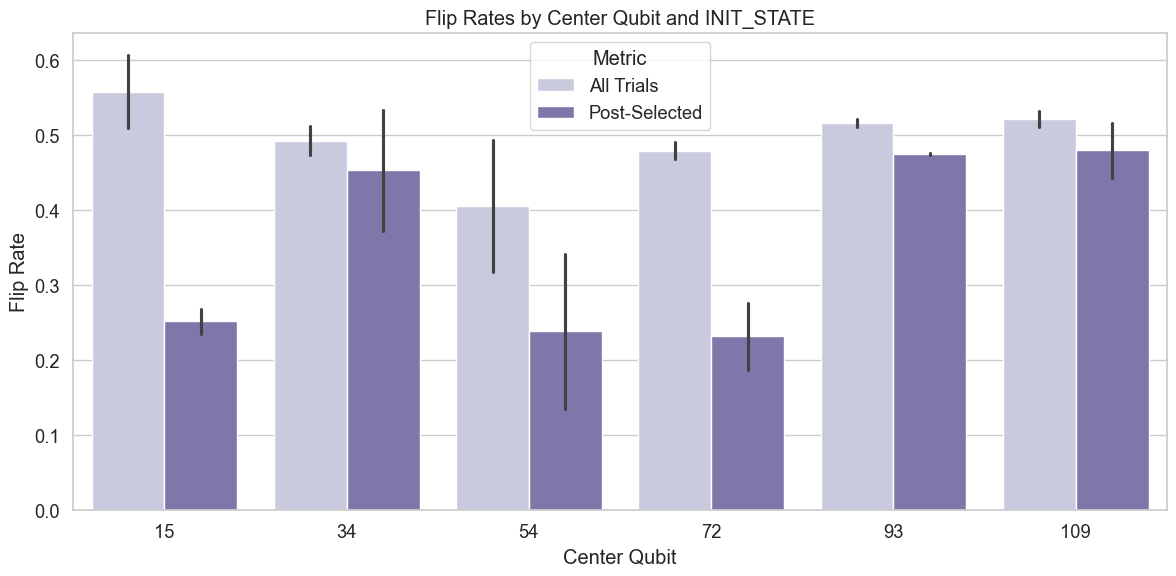

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.2)

# Melt the DataFrame for seaborn
melted = summary2.melt(
    id_vars=["CENTER_Q", "INIT_STATE"],
    value_vars=["raw_flip_rate", "post_flip_rate"],
    var_name="metric",
    value_name="flip_rate"
)

# Replace metric values
melted["metric"] = melted["metric"].replace({
    "raw_flip_rate": "All Trials",
    "post_flip_rate": "Post-Selected"
})

plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x="CENTER_Q", y="flip_rate", hue="metric", dodge=True, palette="Purples")
plt.title("Flip Rates by Center Qubit and INIT_STATE")
plt.xlabel("Center Qubit")
plt.ylabel("Flip Rate")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig('../plots/postsel_combo.png')
plt.show()
